### Main logic of parlimen data to specific mukims within KL

Note: ignore SQL queries, this was from previous work in the beginning stage of the project.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
land = pd.read_csv('data/kl_land_mapping.csv')
land.head()

,mukim,parlimen,weight_by_landmass
0,Mukim Batu,P.115 Batu,0.4
1,Mukim Batu,P.114 Kepong,0.4
2,Mukim Batu,P.117 Segambut,0.2
3,Mukim Petaling,P.122 Seputeh,0.5
4,Mukim Petaling,P.124 Bandar Tun Razak,0.5


In [3]:
land.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mukim               23 non-null     str    
 1   parlimen            23 non-null     str    
 2   weight_by_landmass  23 non-null     float64
dtypes: float64(1), str(2)
memory usage: 684.0 bytes


In [6]:
income_population = pd.read_sql('SELECT * FROM "income_population"', conn, index_col="id")
income_population.head()

,date,parlimen,income_mean,income_median,population
id,,,,,
1,2021-01-01 00:00:00,P.114 Kepong,12419.0,10699.333333,104.200000
2,2022-01-01 00:00:00,P.114 Kepong,12085.0,10412.000000,104.200000
3,2023-01-01 00:00:00,P.114 Kepong,13404.0,10491.000000,106.564318
4,2024-01-01 00:00:00,P.114 Kepong,14723.0,10570.000000,109.847797
5,2025-01-01 00:00:00,P.114 Kepong,14723.0,10570.000000,110.198460


In [7]:
income_population['date'] = pd.to_datetime(income_population['date']).dt.year.astype(str)
income_population['date'].head()

id
1    2021
2    2022
3    2023
4    2024
5    2025
Name: date, dtype: str

In [8]:
highrise = pd.read_sql('SELECT * FROM "highrise"', conn)
highrise['year'] = pd.to_datetime(highrise['month_year']).dt.year.astype(str)
highrise.drop(columns=['month_year', 'id'], inplace=True)

highrise.head()

,property_type,mukim,tenure,land_parcel_area,transaction_price,year
0,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,57.0,469000.0,2023
1,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,197.0,1260000.0,2024
2,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,104.0,650000.0,2024
3,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,104.0,580000.0,2025
4,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,310.0,2000000.0,2022


In [9]:
conn.close()
print(f"Shape of highrise: {highrise.shape}")

Shape of highrise: (19818, 6)


In [10]:
mukim = land.merge(income_population, on='parlimen', how='outer')
mukim.head(10)

,mukim,parlimen,weight_by_landmass,date,income_mean,income_median,population
0,Mukim Batu,P.114 Kepong,0.4,2021,12419.0,10699.333333,104.200000
1,Mukim Batu,P.114 Kepong,0.4,2022,12085.0,10412.000000,104.200000
2,Mukim Batu,P.114 Kepong,0.4,2023,13404.0,10491.000000,106.564318
3,Mukim Batu,P.114 Kepong,0.4,2024,14723.0,10570.000000,109.847797
4,Mukim Batu,P.114 Kepong,0.4,2025,14723.0,10570.000000,110.198460
5,Mukim Batu,P.114 Kepong,0.4,2021,12419.0,10699.333333,104.200000
6,Mukim Batu,P.114 Kepong,0.4,2022,12085.0,10412.000000,104.200000
7,Mukim Batu,P.114 Kepong,0.4,2023,13404.0,10491.000000,106.564318
8,Mukim Batu,P.114 Kepong,0.4,2024,14723.0,10570.000000,109.847797
9,Mukim Batu,P.114 Kepong,0.4,2025,14723.0,10570.000000,110.198460


In [11]:
mukim['final_weight'] = mukim['weight_by_landmass'] * mukim['population']
mukim.head(10)

,mukim,parlimen,weight_by_landmass,date,income_mean,income_median,population,final_weight
0,Mukim Batu,P.114 Kepong,0.4,2021,12419.0,10699.333333,104.200000,41.680000
1,Mukim Batu,P.114 Kepong,0.4,2022,12085.0,10412.000000,104.200000,41.680000
2,Mukim Batu,P.114 Kepong,0.4,2023,13404.0,10491.000000,106.564318,42.625727
3,Mukim Batu,P.114 Kepong,0.4,2024,14723.0,10570.000000,109.847797,43.939119
4,Mukim Batu,P.114 Kepong,0.4,2025,14723.0,10570.000000,110.198460,44.079384
5,Mukim Batu,P.114 Kepong,0.4,2021,12419.0,10699.333333,104.200000,41.680000
6,Mukim Batu,P.114 Kepong,0.4,2022,12085.0,10412.000000,104.200000,41.680000
7,Mukim Batu,P.114 Kepong,0.4,2023,13404.0,10491.000000,106.564318,42.625727
8,Mukim Batu,P.114 Kepong,0.4,2024,14723.0,10570.000000,109.847797,43.939119
9,Mukim Batu,P.114 Kepong,0.4,2025,14723.0,10570.000000,110.198460,44.079384


In [12]:
mukim.groupby(['date', 'mukim']).get_group(('2021', 'Mukim Batu'))

,mukim,parlimen,weight_by_landmass,date,income_mean,income_median,population,final_weight
0,Mukim Batu,P.114 Kepong,0.4,2021,12419.000000,10699.333333,104.2,41.68
5,Mukim Batu,P.114 Kepong,0.4,2021,12419.000000,10699.333333,104.2,41.68
10,Mukim Batu,P.115 Batu,0.4,2021,10430.333333,8887.333333,215.1,86.04
15,Mukim Batu,P.115 Batu,0.4,2021,10430.333333,8887.333333,215.1,86.04
40,Mukim Batu,P.117 Segambut,0.2,2021,21719.666667,14374.666667,249.0,49.80
45,Mukim Batu,P.117 Segambut,0.2,2021,21719.666667,14374.666667,249.0,49.80


In [13]:
total_weight_mukim = mukim.groupby(['date', 'mukim']).agg(
    total_weight = ('final_weight', 'sum')
)
total_weight_mukim

total_weight
date mukim                                 
2021 Kuala Lumpur Town Centre    269.880000
     Mukim Ampang                245.000000
     Mukim Batu                  355.040000
     Mukim Cheras                321.100000
     Mukim Kuala Lumpur          362.820000
     Mukim Petaling              504.300000
     Mukim Setapak               356.000000
     Mukim Ulu Kelang            288.800000
2022 Kuala Lumpur Town Centre    269.880000
     Mukim Ampang                245.000000
     Mukim Batu                  355.040000
     Mukim Cheras                321.100000
     Mukim Kuala Lumpur          362.820000
     Mukim Petaling              504.300000
     Mukim Setapak               356.000000
     Mukim Ulu Kelang            288.800000
2023 Kuala Lumpur Town Centre    276.003628
     Mukim Ampang                250.559096
     Mukim Batu                  363.095925
     Mukim Cheras                328.385820
     Mukim Kuala Lumpur          371.052455
     Mukim Petaling              515.742663
     Mukim Setapak               364.077708
     Mukim Ulu Kelang            295.352927
2024 Kuala Lumpur Town Centre    284.507903
     Mukim Ampang                258.279370
     Mukim Batu                  374.283704
     Mukim Cheras                338.504105
     Mukim Kuala Lumpur          382.485392
     Mukim Petaling              531.633821
     Mukim Setapak               375.295737
     Mukim Ulu Kelang            304.453396
2025 Kuala Lumpur Town Centre    285.416127
     Mukim Ampang                259.103865
     Mukim Batu                  375.478515
     Mukim Cheras                339.584698
     Mukim Kuala Lumpur          383.706385
     Mukim Petaling              533.330935
     Mukim Setapak               376.493779
     Mukim Ulu Kelang            305.425291

In [14]:
mukim = mukim.merge(total_weight_mukim.reset_index(), on=['date', 'mukim'], how='left')
mukim

,mukim,parlimen,weight_by_landmass,date,income_mean,income_median,population,final_weight,total_weight
0,Mukim Batu,P.114 Kepong,0.4,2021,12419.000000,10699.333333,104.200000,41.680000,355.040000
1,Mukim Batu,P.114 Kepong,0.4,2022,12085.000000,10412.000000,104.200000,41.680000,355.040000
2,Mukim Batu,P.114 Kepong,0.4,2023,13404.000000,10491.000000,106.564318,42.625727,363.095925
3,Mukim Batu,P.114 Kepong,0.4,2024,14723.000000,10570.000000,109.847797,43.939119,374.283704
4,Mukim Batu,P.114 Kepong,0.4,2025,14723.000000,10570.000000,110.198460,44.079384,375.478515
...,...,...,...,...,...,...,...,...,...
225,Mukim Cheras,P.124 Bandar Tun Razak,0.5,2021,11183.333333,8990.000000,187.800000,93.900000,321.100000
226,Mukim Cheras,P.124 Bandar Tun Razak,0.5,2022,11142.000000,8769.000000,187.800000,93.900000,321.100000
227,Mukim Cheras,P.124 Bandar Tun Razak,0.5,2023,10853.500000,9064.500000,192.061218,96.030609,328.385820
228,Mukim Cheras,P.124 Bandar Tun Razak,0.5,2024,10565.000000,9360.000000,197.979043,98.989522,338.504105


In [15]:
mukim['income_median_weighted'] = mukim['income_median'] * (mukim['final_weight'] / mukim['total_weight'])
mukim_income = mukim.groupby(['date', 'mukim'])['income_median_weighted'].sum().reset_index()
mukim_income.rename(columns={'date':'year'}, inplace=True)
mukim.head(20)

,mukim,parlimen,weight_by_landmass,date,income_mean,income_median,population,final_weight,total_weight,income_median_weighted
0,Mukim Batu,P.114 Kepong,0.4,2021,12419.000000,10699.333333,104.200000,41.680000,355.040000,1256.050623
1,Mukim Batu,P.114 Kepong,0.4,2022,12085.000000,10412.000000,104.200000,41.680000,355.040000,1222.319063
2,Mukim Batu,P.114 Kepong,0.4,2023,13404.000000,10491.000000,106.564318,42.625727,363.095925,1231.593285
3,Mukim Batu,P.114 Kepong,0.4,2024,14723.000000,10570.000000,109.847797,43.939119,374.283704,1240.867508
4,Mukim Batu,P.114 Kepong,0.4,2025,14723.000000,10570.000000,110.198460,44.079384,375.478515,1240.867508
5,Mukim Batu,P.114 Kepong,0.4,2021,12419.000000,10699.333333,104.200000,41.680000,355.040000,1256.050623
6,Mukim Batu,P.114 Kepong,0.4,2022,12085.000000,10412.000000,104.200000,41.680000,355.040000,1222.319063
7,Mukim Batu,P.114 Kepong,0.4,2023,13404.000000,10491.000000,106.564318,42.625727,363.095925,1231.593285
8,Mukim Batu,P.114 Kepong,0.4,2024,14723.000000,10570.000000,109.847797,43.939119,374.283704,1240.867508
9,Mukim Batu,P.114 Kepong,0.4,2025,14723.000000,10570.000000,110.198460,44.079384,375.478515,1240.867508


In [32]:
mukim_income.to_csv("data/mukim_income.csv", index=False)

['Mukim Batu', 'Kuala Lumpur Town Centre', 'Mukim Setapak', 'Mukim Kuala Lumpur', 'Mukim Ulu Kelang', 'Mukim Ampang', 'Mukim Petaling', 'Mukim Cheras']


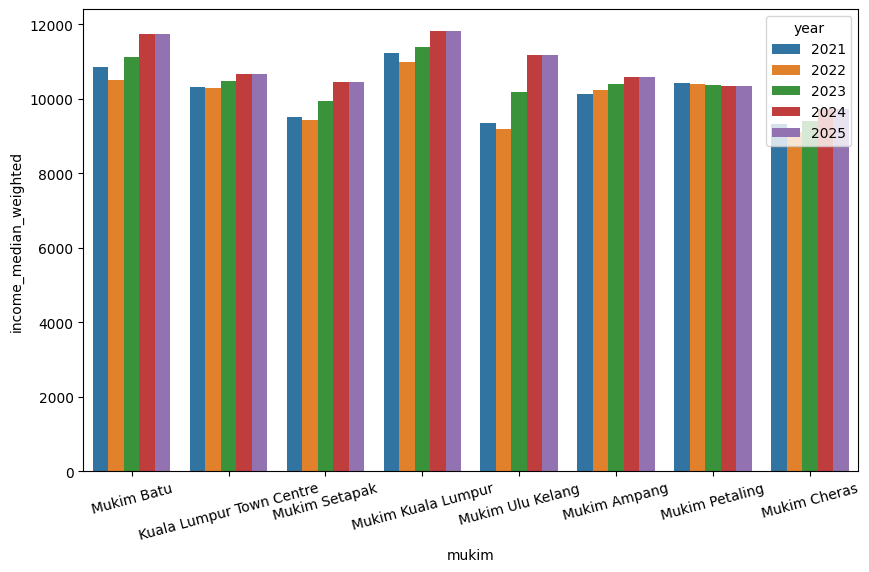

In [17]:
import seaborn as sns

mukim_order = list(mukim['mukim'].unique())
print(mukim_order)

plt.figure(figsize=(10,6))
sns.barplot(
    data=mukim_income,
    x='mukim',
    y='income_median_weighted',
    hue='year',
    order=mukim_order
)
plt.xticks(rotation=15)
plt.show()

In [18]:
df = highrise.merge(mukim_income, on=['year', 'mukim'], how='left')
df.head(20)

,property_type,mukim,tenure,land_parcel_area,transaction_price,year,income_median_weighted
0,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,57.0,469000.0,2023,10479.465763
1,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,197.0,1260000.0,2024,10655.952127
2,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,104.0,650000.0,2024,10655.952127
3,Condominium/Apartment,Kuala Lumpur Town Centre,Leasehold,104.0,580000.0,2025,10655.952127
4,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,310.0,2000000.0,2022,10302.979398
5,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,219.0,1650000.0,2022,10302.979398
6,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,220.0,1590000.0,2023,10479.465763
7,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,418.0,2500000.0,2024,10655.952127
8,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,220.0,1580000.0,2025,10655.952127
9,Condominium/Apartment,Kuala Lumpur Town Centre,Freehold,130.0,1000000.0,2025,10655.952127


In [ ]:
# df.to_csv("data/highrise.csv")